# Graph RAG Pipeline — End-to-End Walkthrough

This notebook walks through every component of the Graph RAG pipeline interactively:

1. **Setup & Checks** — verify Ollama is running and models are available
2. **Load Corpus** — parse the text corpus into LangChain Documents
3. **Build Knowledge Graph** — extract triples and construct a NetworkX graph
4. **Explore the Graph** — query entities, visualize relationships
5. **Build Vector Store** — chunk and embed documents into Chroma
6. **Hybrid Retrieval** — combine vector search + graph expansion
7. **Q&A with the Pipeline** — ask questions and inspect answers
8. **RAGAS Evaluation** — benchmark faithfulness, relevancy, recall, precision
9. **Iterate & Improve** — act on evaluation scores

> **Prerequisites:** Ollama running locally with `llama3.2` and `nomic-embed-text` pulled.
> Run from the project root: `jupyter notebook notebooks/graph_rag_walkthrough.ipynb`

---
## 1. Setup & Checks

In [1]:
# Make sure we're running from the project root so src/ imports work
import os, sys
from pathlib import Path

# If running from notebooks/, go up one level
if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working directory:", Path.cwd())
assert Path("src/pipeline.py").exists(), "src/ not found — run from project root!"
print("✓ Project root confirmed")

Working directory: c:\Users\nidhi.b.priya\OneDrive - Accenture\graph_rag_pipeline\graph_rag_pipeline
✓ Project root confirmed


In [2]:
# Check Ollama is reachable
import urllib.request, json

try:
    with urllib.request.urlopen("http://localhost:11434/api/tags", timeout=5) as resp:
        data = json.loads(resp.read())
    models = [m["name"] for m in data.get("models", [])]
    print("✓ Ollama is running")
    print("  Available models:", models)

    for required in ["llama3.2", "nomic-embed-text"]:
        found = any(required in m for m in models)
        status = "✓" if found else "✗  → run: ollama pull " + required
        print(f"  {status} {required}")

except Exception as e:
    print(f"✗ Cannot reach Ollama: {e}")
    print("  Start it with: ollama serve")

✓ Ollama is running
  Available models: ['nomic-embed-text:latest', 'llama3.2:latest']
  ✓ llama3.2
  ✓ nomic-embed-text


---
## 2. Load Corpus

In [6]:
pip install langchain-ollama


  Using cached langchain_core-1.4.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached langchain_protocol-0.0.15-py3-none-any.whl.metadata (2.4 kB)
  Using cached langsmith-0.8.5-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     --------- ------------------------------ 10.2/43.1 kB ? eta -:--:--
     --------------------------- ---------- 30.7/43.1 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 43.1/43.1 kB 420.9 kB/s eta 0:00:00
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached langchain_core-1.4.0-py3-none-any.whl (548 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.wh

In [13]:
pip install "langchain>=0.3.0" "langchain-core>=0.3.0"

Note: you may need to restart the kernel to use updated packages.


In [4]:
import subprocess
subprocess.run(["pip", "install", "ragas==0.1.21", "--upgrade"], capture_output=False)

CompletedProcess(args=['pip', 'install', 'ragas==0.1.21', '--upgrade'], returncode=0)

In [5]:
from src.graph_builder import KnowledgeGraphBuilder

CORPUS_PATH = "data/corpus.txt"

builder = KnowledgeGraphBuilder(model="llama3.2")
documents = builder.load_corpus(CORPUS_PATH)

print(f"Loaded {len(documents)} documents\n")
for doc in documents:
    words = len(doc.page_content.split())
    print(f"  [{doc.metadata['source']}]  {words} words")

2026-05-24 22:04:28,753 [INFO] Loaded 11 documents from corpus.


Loaded 11 documents

  [transformer_architecture]  113 words
  [bert_model]  97 words
  [gpt_series]  111 words
  [rag_systems]  110 words
  [knowledge_graphs]  118 words
  [vector_databases]  105 words
  [langchain_framework]  101 words
  [ollama_local_llms]  101 words
  [ragas_evaluation]  127 words
  [graph_neural_networks]  106 words
  [embeddings_and_semantic_search]  112 words


In [6]:
# Preview one document
sample = documents[1]
print(f"Source: {sample.metadata['source']}\n")
print(sample.page_content)

Source: bert_model

BERT, which stands for Bidirectional Encoder Representations from Transformers, was developed by Google AI in 2018. BERT is pre-trained on two tasks: masked language modeling and next sentence prediction. Unlike GPT, BERT uses a bidirectional approach, meaning it reads text in both directions simultaneously. BERT was trained on the entire Wikipedia corpus and the BookCorpus dataset. Fine-tuning BERT on downstream tasks like question answering, named entity recognition, and text classification achieves state-of-the-art results. The model uses WordPiece tokenization and supports a maximum sequence length of 512 tokens. BERT influenced many subsequent models including RoBERTa, DistilBERT, and ALBERT.


---
## 3. Build Knowledge Graph

The LLM reads each document and returns `(subject, relation, object)` triples in JSON.
These become nodes and edges in a NetworkX `DiGraph`.

> ⏱ This takes **2–4 minutes** on first run (one LLM call per document). Cached after.

In [10]:
import subprocess
packages = [
    "langchain==0.3.25",
    "langchain-core==0.3.58",
    "langchain-community==0.3.23",
    "langchain-ollama==0.3.2",
    "langchain-chroma==0.2.4",
    "langchain-text-splitters==0.3.8",
]
for pkg in packages:
    print(f"Installing {pkg}...")
    subprocess.run(["pip", "install", pkg], capture_output=False)
print("Done!")

Installing langchain==0.3.25...
Installing langchain-core==0.3.58...
Installing langchain-community==0.3.23...
Installing langchain-ollama==0.3.2...
Installing langchain-chroma==0.2.4...
Installing langchain-text-splitters==0.3.8...
Done!


In [8]:
import os
if os.path.exists("data/knowledge_graph.json"):
    os.remove("data/knowledge_graph.json")
    print("Deleted old cache")

Deleted old cache


In [11]:
import json
from pathlib import Path

GRAPH_CACHE = "data/knowledge_graph.json"

if Path(GRAPH_CACHE).exists():
    print("Loading cached graph…")
    graph = builder.load_graph(GRAPH_CACHE)
else:
    print("Building graph from scratch (this will take a few minutes)…")
    graph = builder.build_graph(documents)
    builder.save_graph(GRAPH_CACHE)
    print("Graph saved to", GRAPH_CACHE)

stats = builder.graph_stats()
print(f"\nGraph stats:")
print(f"  Nodes : {stats['nodes']}")
print(f"  Edges : {stats['edges']}")
print(f"  Density : {stats['density']}")

2026-05-24 22:41:01,430 [INFO] Extracting triples from: transformer_architecture


Building graph from scratch (this will take a few minutes)…


2026-05-24 22:41:27,825 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"
2026-05-24 22:42:10,484 [INFO]   → 10 triples extracted.
2026-05-24 22:42:10,484 [INFO] Extracting triples from: bert_model
2026-05-24 22:42:22,047 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"
2026-05-24 22:42:54,756 [INFO]   → 9 triples extracted.
2026-05-24 22:42:54,757 [INFO] Extracting triples from: gpt_series
2026-05-24 22:43:09,500 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"
2026-05-24 22:43:44,075 [INFO]   → 8 triples extracted.
2026-05-24 22:43:44,077 [INFO] Extracting triples from: rag_systems
2026-05-24 22:43:57,668 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"
2026-05-24 22:44:28,073 [INFO]   → 8 triples extracted.
2026-05-24 22:44:28,076 [INFO] Extracting triples from: knowledge_graphs
2026-05-24 22:44:41,674 [INFO] HTTP Request: POST http://localhost:11434/api/generat

Graph saved to data/knowledge_graph.json

Graph stats:
  Nodes : 99
  Edges : 73
  Density : 0.0075


In [12]:
# Inspect extracted triples for one document
sample_doc = documents[0]  # transformer_architecture
print(f"Triples for: {sample_doc.metadata['source']}\n")

for u, v, data in graph.edges(data=True):
    if any(sample_doc.metadata['source'] in s for s in data.get('sources', [])):
        rels = ", ".join(data['relations'])
        print(f"  {u}  —[{rels}]→  {v}")

Triples for: transformer_architecture

  Transformer  —[was introduced by]→  Vaswani et al.
  Transformer  —[relies entirely on]→  self-attention mechanisms
  Transformer  —[allows the model to jointly attend to information from different representation subspaces]→  multi-head attention mechanism
  Transformer  —[contains no recurrence or convolution]→  input embeddings
  Transformer  —[was originally designed for]→  machine translation
  Transformers  —[consist of]→  an encoder stack and a decoder stack
  multi-head attention layers  —[are part of]→  Transformers
  feed-forward networks  —[are part of]→  Transformers
  GPT  —[is part of]→  the foundation for large language models that use the Transformer
  BERT  —[is part of]→  the foundation for large language models that use the Transformer


In [13]:
# Top 10 most-connected entities
print("Top entities by degree (in + out connections):\n")
top = stats['top_nodes_by_degree']
for name, degree in top:
    bar = "█" * degree
    print(f"  {name:<30} {degree:>3}  {bar}")

Top entities by degree (in + out connections):

  BERT                            10  ██████████
  RAGAS                           10  ██████████
  Ollama                           9  █████████
  RAG                              7  ███████
  Transformer                      5  █████
  Transformers                     3  ███
  Knowledge Graph                  3  ███
  GPT                              2  ██
  the foundation for large language models that use the Transformer   2  ██
  Lewis et al.                     2  ██


---
## 4. Explore the Graph

In [14]:
# Get all relationships for a specific entity
entity = "BERT"  # Try: "Transformer", "LangChain", "RAGAS", "NetworkX"
context = builder.get_entity_context(entity)
print(context)

Knowledge graph context for 'BERT':
  BERT —[is part of]→ the foundation for large language models that use the Transformer
  BERT —[developed by]→ Google AI
  BERT —[pre-trained on]→ masked language modeling
  BERT —[pre-trained on]→ next sentence prediction
  BERT —[uses]→ bidirectional approach
  BERT —[trained on]→ Wikipedia corpus
  BERT —[trained on]→ BookCorpus dataset
  BERT —[influenced]→ RoBERTa
  BERT —[influenced]→ DistilBERT
  BERT —[influenced]→ ALBERT


In [15]:
# Get 1-hop neighbours of an entity
neighbours = builder.get_neighbors(entity, depth=1)
print(f"Neighbours of '{entity}': {neighbours}")

Neighbours of 'BERT': ['DistilBERT', 'the foundation for large language models that use the Transformer', 'Google AI', 'ALBERT', 'next sentence prediction', 'Wikipedia corpus', 'bidirectional approach', 'BookCorpus dataset', 'masked language modeling', 'RoBERTa']


2026-05-24 22:51:00,812 [INFO] Graph visualization saved to data/knowledge_graph.png


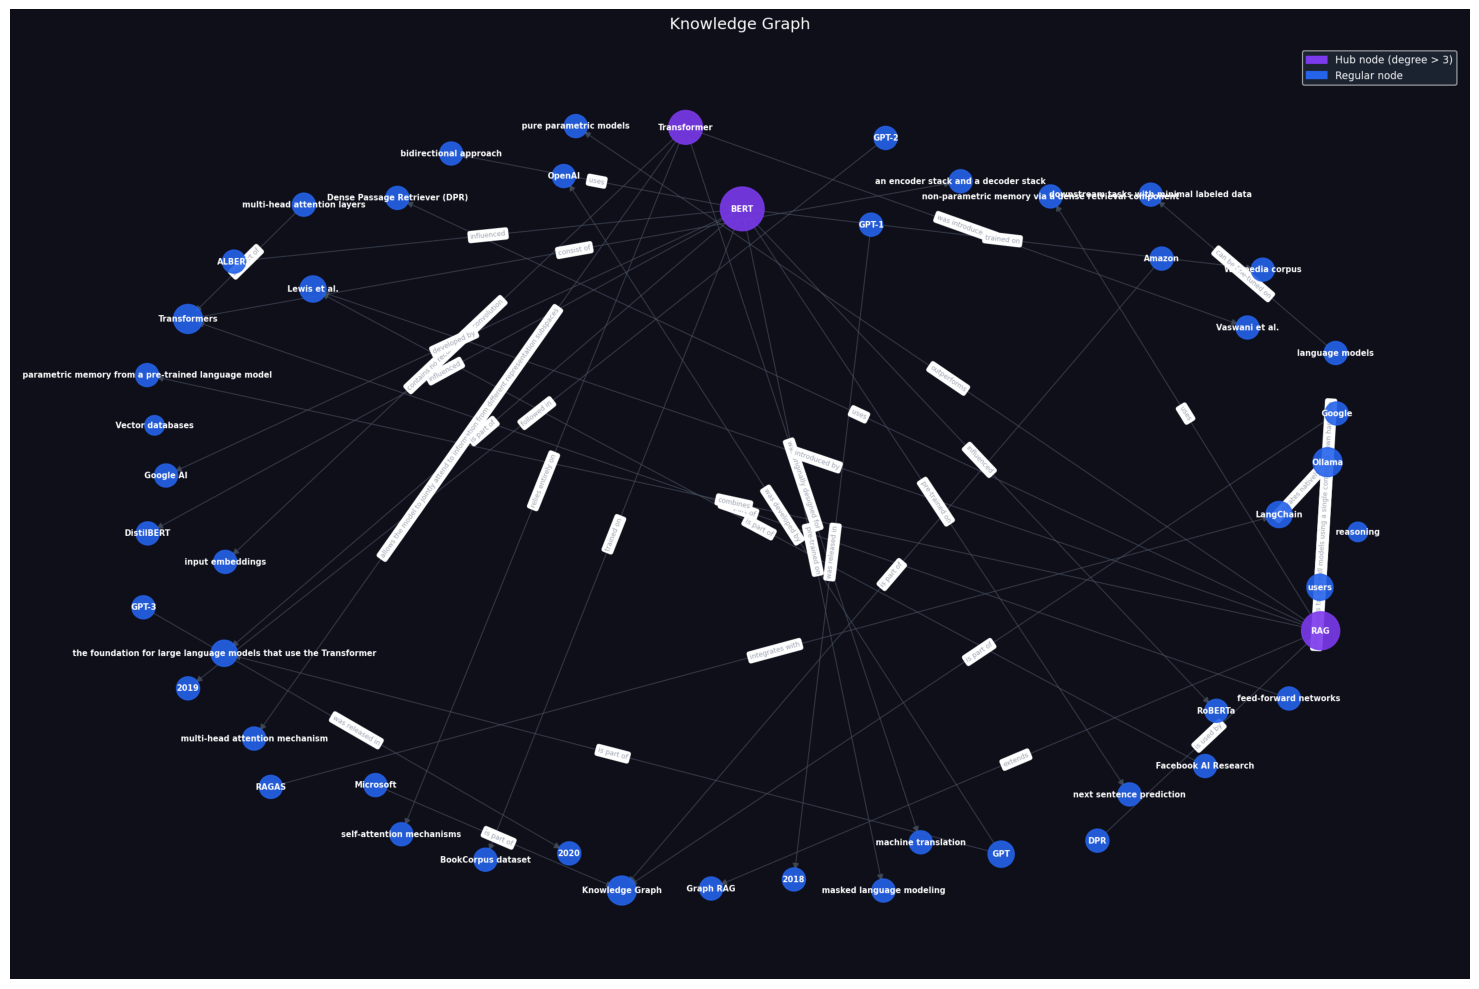

In [16]:
# Visualize the full graph (saves PNG and displays inline)
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

VIZ_PATH = "data/knowledge_graph.png"
builder.visualize(max_nodes=50, output_path=VIZ_PATH)

img = mpimg.imread(VIZ_PATH)
fig, ax = plt.subplots(figsize=(16, 10))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

In [17]:
# Find shortest path between two entities in the graph
import networkx as nx

source_entity = "BERT"
target_entity = "LangChain"

undirected = builder.graph.to_undirected()
try:
    path = nx.shortest_path(undirected, source=source_entity, target=target_entity)
    print(f"Shortest path from '{source_entity}' to '{target_entity}':")
    print("  " + " → ".join(path))
except nx.NetworkXNoPath:
    print("No path found between these entities.")
except nx.NodeNotFound as e:
    print(f"Entity not in graph: {e}")

No path found between these entities.


---
## 5. Build Vector Store

Documents are split into overlapping chunks and embedded using `nomic-embed-text` via Ollama.
Embeddings are persisted in a local Chroma database.

> ⏱ First run takes **1–3 minutes**. Subsequent runs load instantly from disk.

In [3]:
import subprocess
result = subprocess.run(["pip", "install", "langchain-text-splitters", "--upgrade"], 
                       capture_output=True, text=True)
print(result.stdout[-500:])
print(result.stderr[-200:])

smith<1.0.0,>=0.3.45->langchain-core<2.0.0,>=1.2.31->langchain-text-splitters) (2.2.2)
Using cached langchain_text_splitters-1.1.2-py3-none-any.whl (35 kB)




In [6]:
import subprocess
subprocess.run(["pip", "install", "langchain-chroma"], capture_output=False)

CompletedProcess(args=['pip', 'install', 'langchain-chroma'], returncode=0)

In [ ]:
import subprocess
subprocess.run(["pip", "install", "datasets ragas"], capture_output=False)

CompletedProcess(args=['pip', 'install', 'datasets ragas'], returncode=1)

In [1]:
import subprocess
subprocess.run(["pip", "install", "chromadb", "--upgrade", "--force-reinstall"], capture_output=False)

CompletedProcess(args=['pip', 'install', 'chromadb', '--upgrade', '--force-reinstall'], returncode=0)

In [18]:
from src.vector_store import VectorStoreManager

CHROMA_PATH = "data/chroma_db"

vs_manager = VectorStoreManager(
    embedding_model="nomic-embed-text",
    persist_directory=CHROMA_PATH,
    chunk_size=512,
    chunk_overlap=64,
)

vs_manager.build(documents)

print("\nVector store stats:")
for k, v in vs_manager.stats().items():
    print(f"  {k}: {v}")

2026-05-24 22:51:21,622 [INFO] Loading existing Chroma store from data/chroma_db
2026-05-24 22:51:22,208 [INFO] Loaded store with 23 documents.



Vector store stats:
  collection: graph_rag
  embedding_model: nomic-embed-text
  chunk_size: 512
  chunk_overlap: 64
  total_chunks: 23
  persist_directory: data/chroma_db


In [19]:
# Run a raw semantic search to see what's retrieved
query = "how does attention mechanism work in transformers"
results = vs_manager.similarity_search_with_score(query, k=3)

print(f"Query: '{query}'\n")
for doc, score in results:
    source = doc.metadata.get('source', '?')
    chunk  = doc.metadata.get('chunk_index', '?')
    print(f"  Score: {score:.4f} | [{source}] chunk {chunk}")
    print(f"  {doc.page_content[:200]}…\n")

2026-05-24 22:51:37,587 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"


Query: 'how does attention mechanism work in transformers'

  Score: 0.7507 | [transformer_architecture] chunk 1
  . The key innovation is the multi-head attention mechanism, which allows the model to jointly attend to information from different representation subspaces. Positional encodings are added to input emb…

  Score: 0.7688 | [transformer_architecture] chunk 0
  The Transformer architecture was introduced by Vaswani et al. in the 2017 paper "Attention Is All You Need". The model relies entirely on self-attention mechanisms to compute representations of its in…

  Score: 0.7780 | [graph_neural_networks] chunk 1
  . Graph Attention Networks (GAT) use attention mechanisms to weight neighbor contributions. GNNs are applied to molecular property prediction, social network analysis, recommendation systems, and know…



---
## 6. Hybrid Retrieval

The `HybridRetriever` runs two retrieval strategies in parallel and fuses them with **Reciprocal Rank Fusion (RRF)**:
- **Vector search** — semantic similarity via Chroma
- **Graph expansion** — traverse entity neighbourhood to find related chunks

In [20]:
from src.retriever import HybridRetriever

retriever = HybridRetriever(
    graph_builder=builder,
    vector_store=vs_manager,
    graph_hop_depth=1,
)

query = "Who developed BERT and what data was it trained on?"
docs, graph_context = retriever.retrieve(query, k=5)

print(f"Query: '{query}'")
print(f"Retrieved {len(docs)} documents\n")

print("=" * 50)
print("GRAPH CONTEXT INJECTED INTO PROMPT:")
print("=" * 50)
print(graph_context)

print("\n" + "=" * 50)
print("RETRIEVED DOCUMENT CHUNKS:")
print("=" * 50)
for i, doc in enumerate(docs, 1):
    print(f"\n[Doc {i} | {doc.metadata.get('source', '?')}]")
    print(doc.page_content[:300] + "…")

2026-05-24 22:51:42,032 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:51:42,266 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:51:42,501 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:51:42,715 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:51:42,941 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:51:43,171 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"


Query: 'Who developed BERT and what data was it trained on?'
Retrieved 5 documents

GRAPH CONTEXT INJECTED INTO PROMPT:
Knowledge graph context for 'BERT':
  BERT —[is part of]→ the foundation for large language models that use the Transformer
  BERT —[developed by]→ Google AI
  BERT —[pre-trained on]→ masked language modeling
  BERT —[pre-trained on]→ next sentence prediction
  BERT —[uses]→ bidirectional approach
  BERT —[trained on]→ Wikipedia corpus
  BERT —[trained on]→ BookCorpus dataset
  BERT —[influenced]→ RoBERTa
  BERT —[influenced]→ DistilBERT
  BERT —[influenced]→ ALBERT

RETRIEVED DOCUMENT CHUNKS:

[Doc 1 | bert_model]
BERT, which stands for Bidirectional Encoder Representations from Transformers, was developed by Google AI in 2018. BERT is pre-trained on two tasks: masked language modeling and next sentence prediction. Unlike GPT, BERT uses a bidirectional approach, meaning it reads text in both directions simult…

[Doc 2 | gpt_series]
The GPT (Generative Pre-trained Tra

---
## 7. Q&A with the Full Pipeline

In [21]:
from src.pipeline import GraphRAGPipeline

# Build the full pipeline (reuses already-built components from cache)
pipeline = GraphRAGPipeline(
    llm_model="llama3.2",
    embedding_model="nomic-embed-text",
    persist_directory=CHROMA_PATH,
    graph_cache_path=GRAPH_CACHE,
    retrieval_k=5,
)
pipeline.build(CORPUS_PATH)
print("Pipeline ready!")

2026-05-24 22:51:49,267 [INFO] Loading corpus from data/corpus.txt
2026-05-24 22:51:49,302 [INFO] Loaded 11 documents from corpus.
2026-05-24 22:51:49,304 [INFO] Loading cached knowledge graph from data/knowledge_graph.json
2026-05-24 22:51:49,332 [INFO] Graph loaded: 99 nodes, 73 edges.
2026-05-24 22:51:49,334 [INFO] Loading existing Chroma store from data/chroma_db
2026-05-24 22:51:49,353 [INFO] Loaded store with 23 documents.
2026-05-24 22:51:49,354 [INFO] Pipeline ready.


Pipeline ready!


In [22]:
# Ask a question and inspect the full result
question = "What is the difference between GPT-2 and GPT-3?"

result = pipeline.ask(question)

print(f"Q: {result['question']}\n")
print(f"A: {result['answer']}\n")
sources = {d.metadata.get('source', '?') for d in result['source_docs']}
print(f"Sources used: {', '.join(sources)}")

2026-05-24 22:51:52,413 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:51:52,629 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:51:52,829 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:51:53,035 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:51:53,242 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:52:54,486 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"


Q: What is the difference between GPT-2 and GPT-3?

A: Based on the provided knowledge graph context and retrieved documents, I can answer that GPT-2 and GPT-3 differ in terms of their release year.

According to Document 2 | Source: gpt_series, "GPT-2 followed in 2019", implying that GPT-1 was released in 2018. However, the context does not provide a direct comparison between GPT-2 and GPT-3 regarding specific model parameters or capabilities.

It is mentioned in Document 2 | Source: gpt_series that "GPT-3, released in 2020, contained 175 billion parameters and demonstrated few-shot learning capabilities without any fine-tuning". This suggests a significant increase in model size and capabilities compared to GPT-2.

Sources used: gpt_series, graph_neural_networks, ollama_local_llms, langchain_framework, rag_systems


In [23]:
# Ask several questions back-to-back
questions = [
    "How does RAG combine parametric and non-parametric memory?",
    "What Python library is widely used for knowledge graphs in research?",
    "What does RAGAS measure and how does it work?",
]

for q in questions:
    r = pipeline.ask(q)
    print("-" * 60)
    print(f"Q: {q}")
    print(f"A: {r['answer'][:400]}")
    print()

2026-05-24 22:53:19,905 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:53:20,125 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:53:20,367 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:53:20,586 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:53:20,798 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:53:21,021 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:54:07,505 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"


------------------------------------------------------------
Q: How does RAG combine parametric and non-parametric memory?
A: According to the knowledge graph context and retrieved documents, RAG combines parametric memory from a pre-trained language model with non-parametric memory via a dense retrieval component.

The specific details of this combination are as follows:

* Parametric memory comes from a pre-trained language model.
* Non-parametric memory is achieved through a dense retrieval component that uses a Dense



2026-05-24 22:54:30,402 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:54:30,653 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:54:30,864 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:54:31,050 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:15,287 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"


------------------------------------------------------------
Q: What Python library is widely used for knowledge graphs in research?
A: Based on the provided knowledge graph context and retrieved document context, I can answer that NetworkX is a Python library widely used for constructing and analyzing graphs in research settings, including knowledge graphs.



2026-05-24 22:55:21,628 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:21,851 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:22,061 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:22,291 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:22,509 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:22,719 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:22,928 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:23,186 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:23,414 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 22:55:23,610 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.

------------------------------------------------------------
Q: What does RAGAS measure and how does it work?
A: Based on the provided knowledge graph and document contexts, RAGAS measures several key metrics:

1. Faithfulness: whether the generated answer is grounded in the retrieved context
2. Answer relevancy: how relevant the answer is to the original question
3. Context recall: how much of the ground truth is covered by the retrieved context
4. Context precision: the signal-to-noise ratio of the retriev



In [24]:
# Try your own question here!
my_question = "How does Ollama compare to using cloud-based LLM APIs?"

result = pipeline.ask(my_question)
print(f"Q: {result['question']}\n")
print(f"A: {result['answer']}")

2026-05-24 23:01:30,045 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:01:30,230 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:01:30,410 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:01:30,559 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:01:30,715 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:01:30,869 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:02:38,170 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"


Q: How does Ollama compare to using cloud-based LLM APIs?

A: Based on the provided context, Ollama appears to offer several advantages over using cloud-based LLM APIs:

1. **Local deployment**: Ollama allows users to run large language models locally on their own hardware, eliminating the need for cloud dependency.
2. **Faster inference**: Ollama supports GPU acceleration via CUDA and Metal, enabling fast inference on NVIDIA and Apple Silicon hardware.
3. **Simplified model management**: Ollama manages model storage, quantization, and context window configuration automatically, reducing the complexity of managing LLMs.

However, it is unclear how Ollama compares to cloud-based LLM APIs in terms of:

1. **Model availability**: The context does not provide information on whether Ollama offers access to a wider range of models compared to cloud-based APIs.
2. **Cost and pricing**: The context does not mention the cost or pricing structure of using Ollama, which may be comparable to or di

---
## 8. RAGAS Evaluation

RAGAS benchmarks the pipeline on 8 gold Q&A pairs across 4 metrics:

| Metric | Question |
|---|---|
| **Faithfulness** | Is the answer grounded in the retrieved context? |
| **Answer Relevancy** | Does the answer actually address the question? |
| **Context Recall** | Is the ground-truth answer covered by retrieved chunks? |
| **Context Precision** | Are retrieved chunks mostly relevant (low noise)? |

> ⏱ This takes **5–10 minutes** — each metric uses the LLM as a judge internally.

In [30]:
from src.evaluator import RAGASEvaluator, DEFAULT_EVAL_DATASET

# Preview the evaluation dataset
print(f"Evaluation dataset: {len(DEFAULT_EVAL_DATASET)} questions\n")
for item in DEFAULT_EVAL_DATASET:
    print(f"  Q: {item['question']}")
    print(f"  GT: {item['ground_truth'][:100]}…\n")

Evaluation dataset: 8 questions

  Q: Who developed BERT and on which datasets was it trained?
  GT: BERT was developed by Google AI in 2018. It was trained on the entire Wikipedia corpus and the BookC…

  Q: What is the key innovation in the Transformer architecture?
  GT: The key innovation is the multi-head attention mechanism, which allows the model to jointly attend t…

  Q: How does RAG combine parametric and non-parametric memory?
  GT: RAG combines parametric memory from a pre-trained language model with non-parametric memory via a de…

  Q: What metrics does RAGAS use to evaluate RAG pipelines?
  GT: RAGAS measures faithfulness, answer relevancy, context recall, and context precision to evaluate RAG…

  Q: What is Ollama and which models does it support?
  GT: Ollama is an open-source tool for running large language models locally. It supports models includin…

  Q: What is the difference between GPT-2 and GPT-3?
  GT: GPT-2 has 1.5 billion parameters and showed emergent text 

In [26]:
import subprocess
subprocess.run(["pip", "install", "ragas==0.1.21", "--force-reinstall"], capture_output=False)

CompletedProcess(args=['pip', 'install', 'ragas==0.1.21', '--force-reinstall'], returncode=0)

In [28]:
import subprocess
result = subprocess.run(["pip", "show", "ragas"], capture_output=True, text=True)
print(result.stdout)

Name: ragas
Version: 0.1.21
Summary: 
Home-page: 
Author: 
Author-email: 
License: 
Location: C:\Users\nidhi.b.priya\AppData\Local\anaconda3\envs\graphrag\Lib\site-packages
Requires: appdirs, datasets, langchain, langchain-community, langchain-core, langchain-openai, nest-asyncio, numpy, openai, pysbd, tiktoken
Required-by: 



In [31]:
# Run evaluation
evaluator = RAGASEvaluator(pipeline, judge_model="llama3.2")
results = evaluator.evaluate()

2026-05-24 23:25:12,347 [INFO] Running pipeline over 8 evaluation questions…
2026-05-24 23:25:17,994 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:25:18,320 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:25:18,670 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:25:18,976 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:25:19,234 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:25:19,502 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:25:19,748 [INFO] HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-05-24 23:27:35,593 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"
2026-05-24 23:27:47,972 [INFO]   Q: Who developed BERT and on which datasets was it trained?
2026-05-24 23:27:47

In [32]:
# Print the formatted report
evaluator.print_report(results)


  GRAPH RAG PIPELINE — EVALUATION REPORT
  Metric                       Score  Bar
----------------------------------------------------------
  faithfulness               0.181  [███░░░░░░░░░░░░░░░░░] ✗
  answer_relevancy           0.597  [███████████░░░░░░░░░] ⚠
  context_recall             0.890  [█████████████████░░░] ✓
  context_precision          0.631  [████████████░░░░░░░░] ⚠
  composite                  0.575  [███████████░░░░░░░░░] ⚠
  Evaluated on 8 questions



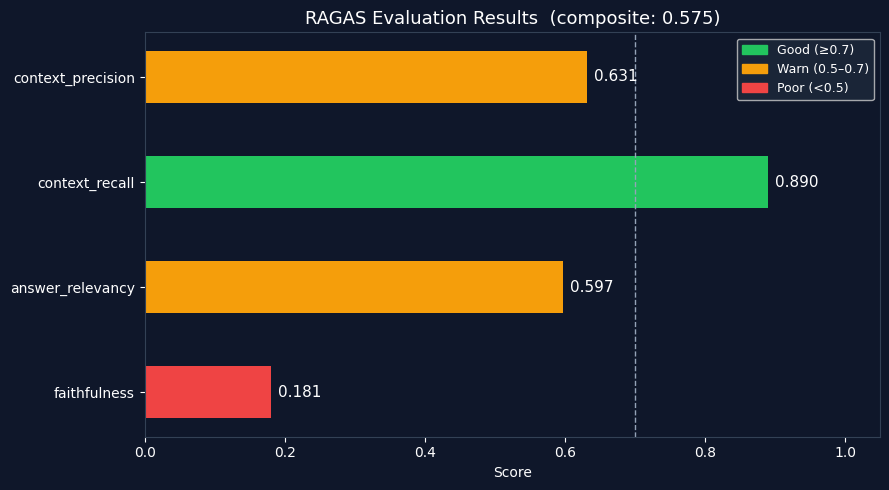

In [33]:
# Plot scores as a bar chart
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

scores = results["scores"]
metrics = [k for k in scores if k != "composite"]
values  = [scores[k] for k in metrics]
colors  = ["#22c55e" if v >= 0.7 else "#f59e0b" if v >= 0.5 else "#ef4444" for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

bars = ax.barh(metrics, values, color=colors, height=0.5, edgecolor="none")
ax.axvline(0.7, color="#94a3b8", linestyle="--", linewidth=1, label="0.7 target")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Score", color="white")
ax.set_title(f"RAGAS Evaluation Results  (composite: {scores['composite']:.3f})",
             color="white", fontsize=13)
ax.tick_params(colors="white")
ax.spines[:].set_color("#334155")

for bar, val in zip(bars, values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", color="white", fontsize=11)

good  = mpatches.Patch(color="#22c55e", label="Good (≥0.7)")
warn  = mpatches.Patch(color="#f59e0b", label="Warn (0.5–0.7)")
bad   = mpatches.Patch(color="#ef4444", label="Poor (<0.5)")
ax.legend(handles=[good, warn, bad], facecolor="#1e293b", labelcolor="white", fontsize=9)

plt.tight_layout()
plt.savefig("data/ragas_scores.png", dpi=130, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

In [34]:
# Save the report to JSON
evaluator.save_report(results, "data/evaluation_report.json")
print("Saved to data/evaluation_report.json")

2026-05-24 23:45:56,104 [INFO] Evaluation report saved to data/evaluation_report.json


Saved to data/evaluation_report.json


---
## 9. Iterate & Improve

Use the evaluator's built-in suggestions to diagnose and fix weak metrics.

In [35]:
suggestions = RAGASEvaluator.suggest_improvements(results["scores"])
print("Improvement suggestions based on your scores:\n")
for i, s in enumerate(suggestions, 1):
    print(f"{i}. {s}\n")

Improvement suggestions based on your scores:

1. Low faithfulness: Try lower temperature or stronger context-grounding in the prompt.

2. Low answer relevancy: Try query rewriting or increase chunk overlap.

3. Low context precision: Reduce retrieval_k or add a re-ranker.



In [ ]:
# Experiment: rebuild with larger retrieval_k and compare
# Uncomment to run — adds ~5 min evaluation time

# pipeline_k8 = GraphRAGPipeline(
#     llm_model="llama3.2",
#     embedding_model="nomic-embed-text",
#     persist_directory=CHROMA_PATH,
#     graph_cache_path=GRAPH_CACHE,
#     retrieval_k=8,           # <-- increased from 5
# )
# pipeline_k8.build(CORPUS_PATH)
# evaluator_k8 = RAGASEvaluator(pipeline_k8)
# results_k8 = evaluator_k8.evaluate()
#
# print("k=5 scores:", results['scores'])
# print("k=8 scores:", results_k8['scores'])

In [36]:
# Add your own Q&A pairs to the evaluation dataset
custom_eval = [
    {
        "question": "What is Reciprocal Rank Fusion?",
        "ground_truth": "Reciprocal Rank Fusion is a score fusion method that combines multiple ranked lists by rewarding documents that appear near the top of several lists."
    },
    # Add more pairs here...
]

# Combine with defaults or use standalone
combined_dataset = DEFAULT_EVAL_DATASET + custom_eval
print(f"Extended evaluation dataset: {len(combined_dataset)} questions")

Extended evaluation dataset: 9 questions


---
## Summary

You've run the complete Graph RAG pipeline:

```
corpus.txt
    │
    ├── KnowledgeGraphBuilder  →  data/knowledge_graph.json
    │                              data/knowledge_graph.png
    │
    ├── VectorStoreManager     →  data/chroma_db/
    │
    ├── HybridRetriever        →  vector search + graph expansion + RRF
    │
    ├── GraphRAGPipeline       →  graph context + doc context + LLM answer
    │
    └── RAGASEvaluator         →  data/evaluation_report.json
                                   data/ragas_scores.png
```

### Files generated
| File | Contents |
|---|---|
| `data/knowledge_graph.json` | Serialized NetworkX graph |
| `data/knowledge_graph.png` | Graph visualization |
| `data/chroma_db/` | Persisted vector embeddings |
| `data/evaluation_report.json` | RAGAS metric scores |
| `data/ragas_scores.png` | Score bar chart |

### Next steps
- Swap in your own documents (see README for corpus format)
- Try a larger model: `ollama pull llama3.1:70b`
- Add a cross-encoder re-ranker to boost context precision
- Increase `graph_hop_depth=2` for multi-hop reasoning